# Задача: выявить корреляцию (или ее отсутствие) между размером словаря токенизатора и качеством модели (выраженном в f1) для задачи сентимент-анализа.
Предлагаемый план работ:
1. Ознакомиться с документацией и реализовать LightningDataModule (https://lightning.ai/docs/pytorch/stable/data/datamodule.html)
 - Загрузить датасет
 - Провести предобработку
 - Выбрать токенизатор (BPE, WordPiece, Unigram)
 - Реализовать collate_fn функцию токенизации для даталодера - encode
 - Добавить даталодеры
2. Ознакомиться с документацией и реализовать LightningModule (https://lightning.ai/docs/pytorch/LTS/common/lightning_module.html)
 - Выбрать и реализовать подходящую архитектуру модели для сентимент-анализа текста
 - Написать прямой проход модели
 - Написать training_step, validation_step, test_step
3. Провести цикл обучений модели
 - Ознакомиться с документацией и выбрать оптимальные настройки для Trainer (https://lightning.ai/docs/pytorch/stable//common/trainer.html)
 - Зафиксировать все гиперпараметры и провести обучение-валидацию-тестирование для 5 значений размера словаря (выбранных на ваше усмотрение)
 - Полученные результаты представить в виде гистограммы или любой другой визуализации

In [ ]:
import logging
import re

import datasets
import matplotlib.pyplot as plt
import pandas as pd
import pytorch_lightning as pl
import seaborn as sns
import tokenizers
import torch
import torchmetrics
from torch import nn, optim
from torch.utils import data


class TipLogger(logging.Filter):
    def filter(self, record) -> bool:
        return "💡 Tip:" not in record.getMessage().strip() and "LOCAL_RANK:" not in record.getMessage().strip()


logging.getLogger("pytorch_lightning.utilities.rank_zero").addFilter(TipLogger)
logging.getLogger("pytorch_lightning.utilities.rank_zero").setLevel(logging.WARNING)

# Data

In [ ]:
class MyDataModule(pl.LightningDataModule):
    def __init__(
        self,
        df_pathes: tuple[str, str] = ("positive.csv", "negative.csv"),
        num_workers: int = 12,
        batch_size: int = 16,
        vocab_size: int = 5000,
        max_length: int = 256,
        tokenizer_type: str = "bpe",
    ) -> None:
        super().__init__()
        self.df_pathes = df_pathes
        self.num_workers = num_workers
        self.batch_size = batch_size
        self.vocab_size = vocab_size
        self.max_length = max_length
        self.tokenizer_type = tokenizer_type

        self.stop_words = {
            "этой",
            "а",
            "была",
            "ведь",
            "<",
            "ну",
            "$",
            "через",
            "где",
            "почти",
            "вы",
            "что",
            "конечно",
            "теперь",
            "похуй",
            "к",
            "можно",
            "этот",
            ",",
            "мне",
            "еще",
            "наконец",
            "под",
            "зачем",
            ">",
            "то",
            "кто",
            "между",
            "там",
            "бы",
            "может",
            "тот",
            "их",
            "ж",
            ";",
            "за",
            "когда",
            "%",
            "вот",
            "будто",
            "по",
            "`",
            "rt",
            "вроде",
            "с",
            "тем",
            "над",
            "никогда",
            "}",
            "бл",
            "про",
            "об",
            "уж",
            "надо",
            "разве",
            "какой",
            "после",
            "них",
            "нибудь",
            "меня",
            "даже",
            "~",
            "блять",
            "/",
            "^",
            "кстати",
            "…",
            "него",
            "более",
            "всегда",
            "опять",
            "только",
            "та",
            "типа",
            "в",
            "все",
            "-",
            "нельзя",
            "хуйню",
            "ним",
            "ничего",
            "всего",
            "перед",
            "потому",
            "совсем",
            "до",
            "чтоб",
            "как",
            "]",
            "же",
            "один",
            "но",
            "чем",
            "чтобы",
            "от",
            "этом",
            "тоже",
            "!",
            "?",
            "потом",
            "они",
            "хоть",
            "во",
            "#",
            "здесь",
            "тут",
            "вдруг",
            "раз",
            ".",
            "'",
            "...",
            "если",
            "у",
            "*",
            "он",
            "ли",
            "@",
            "{",
            "уже",
            "чего",
            "другой",
            "бля",
            "она",
            "было",
            "я",
            "(",
            ")",
            "быть",
            "свою",
            "да",
            "впрочем",
            "этого",
            "много",
            "куда",
            '"',
            ":",
            "со",
            "при",
            "иногда",
            "\\",
            "=",
            "о",
            "такой",
            "так",
            "без",
            "чуть",
            "том",
            "всю",
            "был",
            "нее",
            "будет",
            "на",
            "есть",
            "или",
            "эту",
            "&",
            "|",
            "какая",
            "пиздец",
            "тогда",
            "сейчас",
            "ней",
            "_",
            "[",
            "всех",
            "были",
            "из",
            "того",
            "+",
        }

        self.tokenizer = None

    def setup(self, stage: str) -> None:
        if self.tokenizer is not None:
            return

        dfs = []
        for df_path in self.df_pathes:
            dfs.append(
                pd.read_csv(
                    df_path,
                    header=None,
                    sep=";",
                    names=[
                        "id",
                        "tdate",
                        "tname",
                        "ttext",
                        "ttype",
                        "trep",
                        "trtv",
                        "tfav",
                        "tstcount",
                        "tfol",
                        "tfrien",
                        "listcount",
                    ],
                    nrows=10000,
                )
            )
        df = pd.concat(dfs)
        df["ttype"] = df["ttype"].apply(lambda label: int(label == 1))
        df["ttext"] = df["ttext"].apply(lambda text: self.__clean_text(text))
        df = df[["ttext", "ttype"]]

        df = df.sample(frac=1).reset_index(drop=True)
        n = len(df)
        train_ratio, val_ratio = 0.7, 0.2
        train_end = int(train_ratio * n)
        val_end = int((train_ratio + val_ratio) * n)

        train_df = df.iloc[:train_end]
        val_df = df.iloc[train_end:val_end]
        test_df = df.iloc[val_end:]

        self.ds = datasets.DatasetDict(
            {
                "train": datasets.Dataset.from_pandas(train_df),
                "val": datasets.Dataset.from_pandas(val_df),
                "test": datasets.Dataset.from_pandas(test_df),
            }
        )

        # TODO: try Unigram instead of BPE
        special_tokens = ["[UNK]", "[CLS]", "[SEP]", "[PAD]", "[MASK]"]
        if self.tokenizer_type == "bpe":
            tokenizer = tokenizers.Tokenizer(tokenizers.models.BPE(unk_token="[UNK]"))
            trainer = tokenizers.trainers.BpeTrainer(vocab_size=self.vocab_size, special_tokens=special_tokens)
        else:
            tokenizer = tokenizers.Tokenizer(tokenizers.models.Unigram())
            trainer = tokenizers.trainers.UnigramTrainer(
                unk_token="[UNK]", vocab_size=self.vocab_size, special_tokens=special_tokens, show_progress=False
            )
            tokenizer.pre_tokenizer = tokenizers.pre_tokenizers.ByteLevel(add_prefix_space=False)

        tokenizer.train_from_iterator(self.ds["train"]["ttext"], trainer=trainer)

        tokenizer.enable_truncation(self.max_length)
        tokenizer.enable_padding(pad_token="[PAD]", direction="left")
        self.tokenizer = tokenizer

    def __clean_text(self, text: str, pattern: str = r"@\w+|https?://\S+|#\w+|™") -> str:
        """Preproc from lab1"""
        text = re.sub(pattern, "", text.lower().strip())
        text = re.sub(r"\s+", " ", text).strip()

        # смех
        text = re.sub(r"(ах){2,}", r"ахах", text)
        text = re.sub(r"(ха){2,}", r"ха", text)

        text = re.sub(r"(\w)\1+", r"\1", text)  # блиин -> блин

        text = re.sub(r"(^|\s)[^\w\s]+(\w)", r"\1\2", text)  # -слушай -> слушай
        text = re.sub(r"(\w)[^\w\s]+($|\s)", r"\1\2", text)  # человек… -> человек

        return " ".join([word for word in text.split() if word not in self.stop_words])

    def __get_dataloader(self, ds: data.Dataset, is_train: bool = False) -> data.DataLoader:
        return data.DataLoader(
            ds,
            batch_size=self.batch_size,
            num_workers=self.num_workers,
            collate_fn=self.encode,
            pin_memory=torch.cuda.is_available() and self.num_workers > 1,
            shuffle=is_train,
        )

    def train_dataloader(self) -> data.DataLoader:
        return self.__get_dataloader(self.ds["train"], True)

    def val_dataloader(self) -> data.DataLoader:
        return self.__get_dataloader(self.ds["val"], False)

    def test_dataloader(self) -> data.DataLoader:
        return self.__get_dataloader(self.ds["test"], False)

    def encode(self, batch: tuple[str, int]) -> dict:
        # TODO: tokenize, pad and truncate
        input_ids = self.tokenizer.encode_batch([i["ttext"] for i in batch])
        input_ids = torch.tensor([i.ids for i in input_ids])
        label = torch.tensor([i["ttype"] for i in batch])
        return {"input_ids": input_ids, "label": label}

# Model

In [ ]:
class RNNModel(nn.Module):
    def __init__(self, vocab_size: int, emb_size: int, hidden_size: int, output_size: int, padding_idx: int) -> None:
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_size, padding_idx)
        self.rnn = nn.RNN(emb_size, hidden_size, num_layers=2, batch_first=True, dropout=0.1)
        self.ln = nn.LayerNorm(hidden_size)
        self.act = nn.SiLU()
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, features: torch.Tensor) -> torch.Tensor:
        embs = self.emb(features)
        out, _ = self.rnn(embs)
        out = out.mean(dim=1)
        out = self.act(self.ln(out))
        return self.fc(out)


class RNNLightningModule(pl.LightningModule):
    def __init__(self, vocab_size: int, emb_size: int, hidden_size: int, output_size: int, padding_idx: int) -> None:
        super().__init__()
        # TODO: add your model
        self.model = RNNModel(vocab_size, emb_size, hidden_size, output_size, padding_idx)
        self.criterion = nn.CrossEntropyLoss()
        self.metrics = nn.ModuleDict(
            {
                "_" + split: torchmetrics.F1Score(task="multiclass", num_classes=output_size)
                for split in ["train", "val", "test"]
            }
        )

    def forward(self, features: torch.Tensor) -> torch.Tensor:
        return self.model(features)

    def __shared_step(self, batch: tuple, step_type: str) -> torch.Tensor:
        logits = self(batch["input_ids"])
        loss = self.criterion(logits, batch["label"])
        m_out = self.metrics["_" + step_type](logits, batch["label"])

        self.log(f"{step_type}_loss", loss)
        self.log(f"{step_type}_f1", m_out, on_epoch=True)

        return loss

    def training_step(self, batch: tuple, batch_idx: int) -> torch.Tensor:
        return self.__shared_step(batch, "train")

    def validation_step(self, batch: tuple, batch_idx: int) -> torch.Tensor:
        return self.__shared_step(batch, "val")

    def test_step(self, batch: tuple, batch_idx: int) -> torch.Tensor:
        return self.__shared_step(batch, "test")

    def configure_optimizers(self) -> optim.Adam:
        return optim.Adam(self.model.parameters(), lr=0.001)

# Trainer

In [ ]:
vocab_sizes = range(1000, 20_000, 4000)
tokenizer_types = ["unigram", "bpe"]

max_length = 256
embd_size = 256
hidden_size = 256
seed = 42
results = []

for tokenizer_type in tokenizer_types:
    for vocab_size in vocab_sizes:
        print(f"{tokenizer_type=}, {vocab_size=}")
        pl.seed_everything(seed, verbose=False)
        dm = MyDataModule(
            vocab_size=vocab_size, max_length=max_length, num_workers=4, batch_size=512, tokenizer_type=tokenizer_type
        )
        dm.setup("")
        model = RNNLightningModule(
            vocab_size=vocab_size,
            emb_size=embd_size,
            hidden_size=hidden_size,
            output_size=2,
            padding_idx=dm.tokenizer.token_to_id("[PAD]"),
        )

        early_stop = pl.callbacks.EarlyStopping(
            monitor="val_f1",
            mode="max",
            patience=2,
            min_delta=0.02,
            verbose=False,
        )

        checkpointer = pl.callbacks.ModelCheckpoint(
            monitor="val_f1",
            mode="max",
            dirpath="checkpoints",
            filename=f"ckpt_{tokenizer_type}_{vocab_size}",
            auto_insert_metric_name=False,
            save_top_k=1,
        )

        trainer = pl.Trainer(
            max_epochs=10,
            num_sanity_val_steps=0,
            enable_model_summary=False,
            gradient_clip_val=1,
            deterministic=True,
            benchmark=False,
            callbacks=[early_stop, checkpointer],
            logger=False,
        )
        trainer.fit(model=model, datamodule=dm)
        test_res = trainer.test(datamodule=dm, ckpt_path="best")[0]

        results.append(
            {
                "tokenizer_type": tokenizer_type,
                "vocab_size": vocab_size,
                "F1": test_res["test_f1"],
                "loss": test_res["test_loss"],
            }
        )

tokenizer_type='unigram', vocab_size=1000


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

...

/home/ext-yudin-a@ad.speechpro.com/NLP/.pixi/envs/default/lib/python3.10/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /home/ext-yudin-a@ad.speechpro.com/NLP/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│          test_f1          │    0.7095000147819519     │
│         test_loss         │    0.7908549308776855     │
└───────────────────────────┴───────────────────────────┘

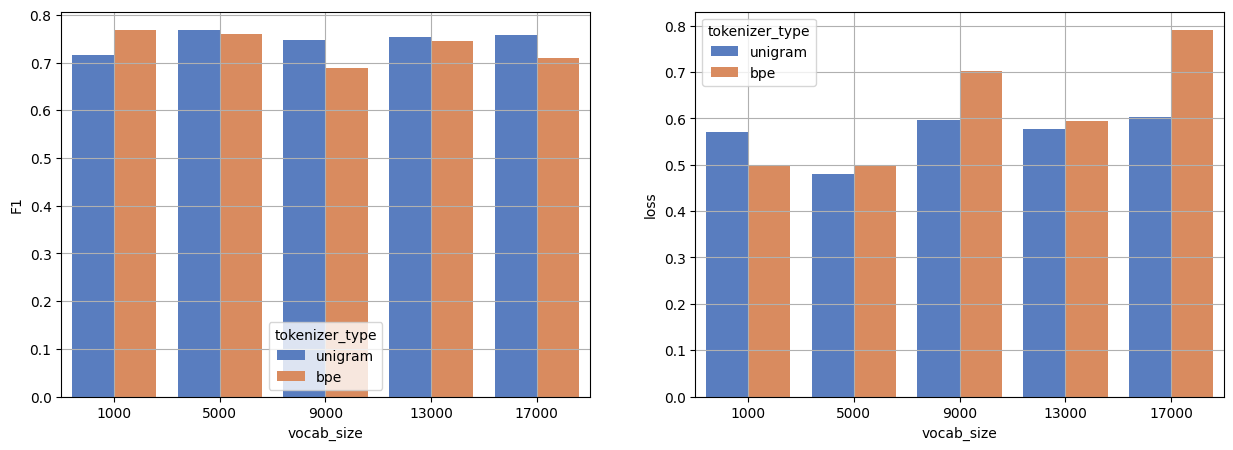

In [ ]:
metrics_df = pd.DataFrame(results)

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
sns.barplot(data=metrics_df, x="vocab_size", y="F1", hue="tokenizer_type", ax=axs[0], palette="muted")
sns.barplot(data=metrics_df, x="vocab_size", y="loss", hue="tokenizer_type", ax=axs[1], palette="muted")

axs[0].grid(True)
axs[1].grid(True)
plt.show()